# QS World Ranking — Regression-Based Classification

**Goal.** Classify each institution into a performance tier — **Low**, **Medium** or **High** — using regression models, then binning the predicted score.

The target `score_category` is derived from `overall_score`, grouped into three tiers:

| Tier | Overall Score range |
|------|--------------------|
| Low | 11 – 18 |
| Medium | 19 – 28 |
| High | 29 – 100 |

**Method — Regression + Binning.** Each model predicts the continuous `overall_score`; the prediction is mapped onto the three tiers using the cut-offs above (Low ≤ 18, Medium ≤ 28, else High).

**Models compared:**

- **Linear Regression** (ordinary least squares)
- **Ridge Regression** (L2 penalty)
- **Lasso Regression** (L1 penalty)
- **Elastic Net** (mixed L1/L2 penalty)

Penalty strengths for Ridge / Lasso / Elastic Net are chosen automatically inside each pipeline (`RidgeCV` / `LassoCV` / `ElasticNetCV`).

**Two feature sets** are evaluated for every model:

- **Without ranks** — the eight QS component *scores* plus institutional attributes (size, research intensity, funding type).
- **With ranks** — the same, plus the eight QS component *rank* columns.

Every model is assessed on a hold-out test set **and** with 10-fold cross-validation, with a single grouped comparison of all regressions (with ranks vs without ranks).

> Note: `overall_score` defines the target and is never a feature. The overall QS `rank` / `rank_numeric` is a direct ordering of `overall_score`, so it too is excluded. Only the eight *component* rank columns are added in the "with ranks" set.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, ElasticNetCV,
)
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

## 1. Load the cleaned data

In [3]:
df = pd.read_excel("QS_world_ranking.xlsx", sheet_name="Cleaned_Data")

# Dropping stray empty/unnamed spillover columns and tiding the headers
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (7431, 29)


,year,institution,country,academic_reputation_rank,academic_reputation_score,citations_per_faculty_rank,citations_per_faculty_score,employer_reputation_rank,employer_reputation_score,employment_outcomes_rank,employment_outcomes_score,faculty_student_ratio_rank,faculty_student_ratio_score,international_faculty_ratio_rank,international_faculty_ratio_score,international_research_network_rank,international_research_network_score,international_students_ratio_rank,international_students_ratio_score,research,size,rank_numeric,size_ordinal,research_ordinal,Private,Public,score_category,overall_score,rank
0,2023,Massachusetts Institute of Technology (MIT),United States,5,100.0,5,100.0,4,100.0,3,100.0,14,100.0,54,100.0,58,96.1,109,90.0,VH,M,1.0,2,4,1,0,High,100.0,1
1,2023,University of Cambridge,United Kingdom,2,100.0,55,92.3,2,100.0,9,100.0,11,100.0,60,100.0,6,99.5,70,96.3,VH,L,2.0,3,4,0,1,High,98.8,2
2,2023,Stanford University,United States,4,100.0,9,99.9,5,100.0,2,100.0,6,100.0,74,99.8,55,96.3,235,60.3,VH,L,3.0,3,4,1,0,High,98.5,3
3,2023,University of Oxford,United Kingdom,3,100.0,64,90.0,3,100.0,7,100.0,8,100.0,101,98.8,3,99.9,54,98.4,VH,L,4.0,3,4,0,1,High,98.4,4
4,2023,Harvard University,United States,1,100.0,2,100.0,1,100.0,1,100.0,35,99.4,228,76.9,1,100.0,212,66.9,VH,L,5.0,3,4,1,0,High,97.6,5


## 2. Target variable — the three performance tiers

score_category
Low       2612
High      2466
Medium    2353
Name: count, dtype: int64


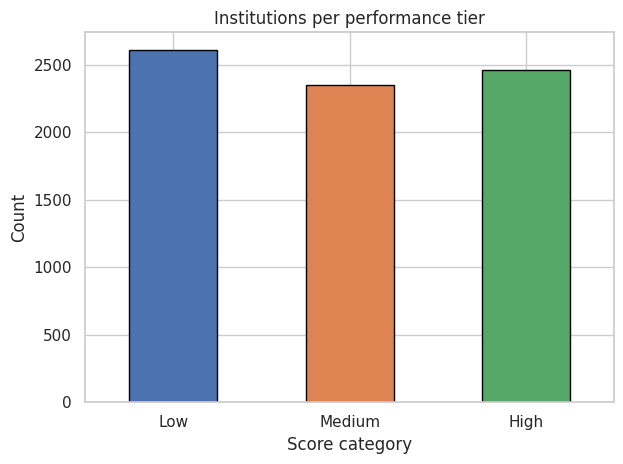

In [4]:
print(df["score_category"].value_counts())

ax = df["score_category"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black"
)
ax.set_title("Institutions per performance tier")
ax.set_xlabel("Score category")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Confirming the tiers are the overall_score bands described in the brief
tier_ranges = (
    df.groupby("score_category")["overall_score"]
      .agg(["min", "max", "count"])
      .reindex(["Low", "Medium", "High"])
)
print(tier_ranges)

                      min         max  count
score_category                              
Low             11.418222   18.035674   2612
Medium          18.997531   28.300000   2353
High            28.329192  100.000000   2466


## 3. Clean the component rank columns

The eight `*_rank` columns are stored as text and contain banded values such as `501+`, `601+`. We strip the `+` and convert to a numeric rank so they can be used as regression features.

In [6]:
rank_cols = [
    "academic_reputation_rank",
    "citations_per_faculty_rank",
    "employer_reputation_rank",
    "employment_outcomes_rank",
    "faculty_student_ratio_rank",
    "international_faculty_ratio_rank",
    "international_research_network_rank",
    "international_students_ratio_rank",
]

for c in rank_cols:
    df[c] = (
        df[c].astype(str)
             .str.replace("+", "", regex=False)
             .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Any values that failed to parse -> fill with the column's worst (max) rank
df[rank_cols] = df[rank_cols].fillna(df[rank_cols].max())

print(df[rank_cols].describe().T[["min", "max", "mean"]].round(1))

                                     min     max   mean
academic_reputation_rank             1.0   701.0  490.9
citations_per_faculty_rank           1.0   934.0  545.7
employer_reputation_rank             1.0   778.0  491.1
employment_outcomes_rank             1.0  1012.0  547.9
faculty_student_ratio_rank           1.0   801.0  547.7
international_faculty_ratio_rank     1.0  1198.0  546.4
international_research_network_rank  1.0  1239.0  546.4
international_students_ratio_rank    1.0  1148.0  545.4


## 4. Feature sets, models and the tier-binning rule

In [7]:
score_features = [
    "academic_reputation_score",
    "citations_per_faculty_score",
    "employer_reputation_score",
    "employment_outcomes_score",
    "faculty_student_ratio_score",
    "international_faculty_ratio_score",
    "international_students_ratio_score",
    "international_research_network_score",
]
attribute_features = ["size_ordinal", "research_ordinal", "Private", "Public"]

feature_sets = {
    "Without ranks": score_features + attribute_features,
    "With ranks":    score_features + attribute_features + rank_cols,
}
for name, feats in feature_sets.items():
    print(f"{name:14s}: {len(feats)} features")

# Regression target (continuous) and classification target (tier)
y_score = df["overall_score"]
y_tier  = df["score_category"]
tier_order = ["Low", "Medium", "High"]


def score_to_tier(s):
    """Map a continuous overall_score onto the three tiers (brief cut-offs)."""
    return np.select([s <= 18, s <= 28], ["Low", "Medium"], default="High")


def make_models():
    """Fresh estimator instances. CV variants pick their own penalty strength."""
    return {
        "Linear":      LinearRegression(),
        "Ridge":       RidgeCV(alphas=np.logspace(-3, 3, 25)),
        "Lasso":       LassoCV(cv=5, max_iter=20000,
                               random_state=RANDOM_STATE),
        "ElasticNet":  ElasticNetCV(cv=5, max_iter=20000,
                                    l1_ratio=[0.2, 0.5, 0.8],
                                    random_state=RANDOM_STATE),
    }

model_names = list(make_models().keys())
print("\nModels:", model_names)

Without ranks : 12 features
With ranks    : 20 features

Models: ['Linear', 'Ridge', 'Lasso', 'ElasticNet']


## 5. Hold-out evaluation (all models × both feature sets)

We fist split 75/25 (stratified on the tier), standardise on the training data, fit each regression on `overall_score`, then bin the predicted score into tiers.

In [8]:
holdout_rows = []
holdout_detail = {}   # (model, feature set) -> (y_true, y_pred)

for set_name, feats in feature_sets.items():
    X = df[feats]
    X_tr, X_te, ys_tr, ys_te, yt_tr, yt_te = train_test_split(
        X, y_score, y_tier, test_size=0.25,
        random_state=RANDOM_STATE, stratify=y_tier,
    )
    for model_name, est in make_models().items():
        pipe = make_pipeline(StandardScaler(), est)
        pipe.fit(X_tr, ys_tr)
        pred_tier = score_to_tier(pipe.predict(X_te))
        acc = accuracy_score(yt_te, pred_tier)
        r2 = pipe.score(X_te, ys_te)
        holdout_rows.append({"Model": model_name, "Feature set": set_name,
                             "R2 (score)": r2, "Tier accuracy": acc})
        holdout_detail[(model_name, set_name)] = (yt_te, pred_tier)

holdout = pd.DataFrame(holdout_rows)
holdout_pivot = holdout.pivot(index="Model", columns="Feature set",
                              values="Tier accuracy").reindex(model_names)
print("Hold-out tier accuracy:\n")
print(holdout_pivot.round(4))
print("\nFull hold-out table:\n")
print(holdout.round(4).to_string(index=False))

Hold-out tier accuracy:

Feature set  With ranks  Without ranks
Model                                 
Linear           0.8977         0.8509
Ridge            0.8983         0.8509
Lasso            0.8977         0.8509
ElasticNet       0.9004         0.8509

Full hold-out table:

     Model   Feature set  R2 (score)  Tier accuracy
    Linear Without ranks      0.9780         0.8509
     Ridge Without ranks      0.9780         0.8509
     Lasso Without ranks      0.9780         0.8509
ElasticNet Without ranks      0.9780         0.8509
    Linear    With ranks      0.9837         0.8977
     Ridge    With ranks      0.9837         0.8983
     Lasso    With ranks      0.9837         0.8977
ElasticNet    With ranks      0.9838         0.9004


### Visualizing Hold-out Performance

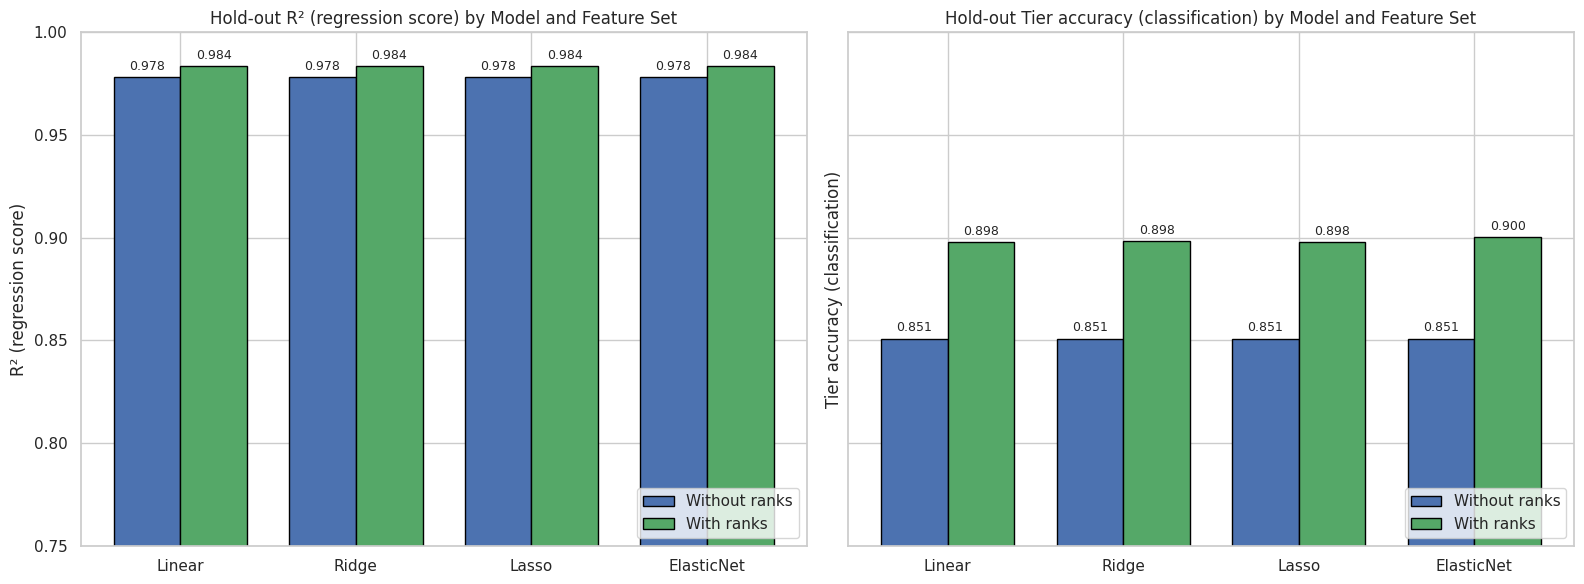

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
metric_names = {"R2 (score)": "R² (regression score)", "Tier accuracy": "Tier accuracy (classification)"}

for i, metric in enumerate(["R2 (score)", "Tier accuracy"]):
    ax = axes[i]

    without = [holdout[(holdout["Model"] == m) & (holdout["Feature set"] == "Without ranks")][metric].iloc[0] for m in model_names]
    with_r   = [holdout[(holdout["Model"] == m) & (holdout["Feature set"] == "With ranks")][metric].iloc[0] for m in model_names]

    x = np.arange(len(model_names))
    w = 0.38

    b1 = ax.bar(x - w/2, without, w, label="Without ranks", color="#4C72B0", edgecolor="black")
    b2 = ax.bar(x + w/2, with_r,  w, label="With ranks", color="#55A868", edgecolor="black")

    ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
    ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)

    ax.set_xticks(x, model_names)
    ax.set_ylabel(metric_names[metric])
    ax.set_title(f"Hold-out {metric_names[metric]} by Model and Feature Set")
    ax.set_ylim(0.75, 1)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6. K-fold cross-validation (all models × both feature sets)

10-fold cross-validation of the full regression-plus-binning pipeline. Scaling (and each model's penalty selection) is fitted inside every fold to avoid leakage. We record the tier accuracy on each held-out fold.

In [10]:
def cv_tier_accuracy(estimator, feats, k=10):
    X = df[feats]
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    accs = []
    for tr_idx, va_idx in kf.split(X):
        pipe = make_pipeline(StandardScaler(), clone(estimator))
        pipe.fit(X.iloc[tr_idx], y_score.iloc[tr_idx])
        pred_tier = score_to_tier(pipe.predict(X.iloc[va_idx]))
        accs.append(accuracy_score(y_tier.iloc[va_idx], pred_tier))
    return np.array(accs)

cv_scores = {}   # (model, feature set) -> array of fold accuracies
for set_name, feats in feature_sets.items():
    for model_name, est in make_models().items():
        cv_scores[(model_name, set_name)] = cv_tier_accuracy(est, feats)
    print(f"Done: {set_name}")

# summary table
cv_rows = []
for (model_name, set_name), arr in cv_scores.items():
    cv_rows.append({"Model": model_name, "Feature set": set_name,
                    "CV mean": arr.mean(), "CV std": arr.std(),
                    "CV min": arr.min(), "CV max": arr.max()})
cv_summary = pd.DataFrame(cv_rows)
cv_mean_pivot = cv_summary.pivot(index="Model", columns="Feature set",
                                 values="CV mean").reindex(model_names)
print("\n10-fold CV mean tier accuracy:\n")
print(cv_mean_pivot.round(4))

Done: Without ranks
Done: With ranks

10-fold CV mean tier accuracy:

Feature set  With ranks  Without ranks
Model                                 
Linear           0.8915         0.8474
Ridge            0.8913         0.8474
Lasso            0.8917         0.8469
ElasticNet       0.8913         0.8482


## 7. Comparison of all regressions — with ranks vs without ranks

A single grouped bar chart of the 10-fold CV mean accuracy (error bars = CV standard deviation), and a grouped boxplot of the per-fold distributions.

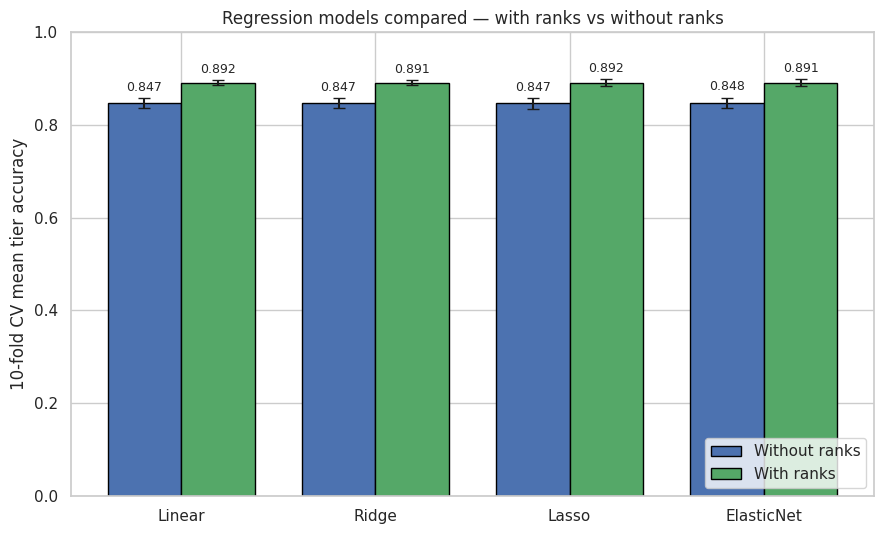

In [11]:
without = [cv_scores[(m, "Without ranks")].mean() for m in model_names]
with_r   = [cv_scores[(m, "With ranks")].mean()    for m in model_names]
without_sd = [cv_scores[(m, "Without ranks")].std() for m in model_names]
with_sd    = [cv_scores[(m, "With ranks")].std()    for m in model_names]

x = np.arange(len(model_names))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - w/2, without, w, yerr=without_sd, capsize=4,
            label="Without ranks", color="#4C72B0", edgecolor="black")
b2 = ax.bar(x + w/2, with_r,  w, yerr=with_sd, capsize=4,
            label="With ranks", color="#55A868", edgecolor="black")
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)
ax.set_xticks(x, model_names)
ax.set_ylabel("10-fold CV mean tier accuracy")
ax.set_title("Regression models compared — with ranks vs without ranks")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

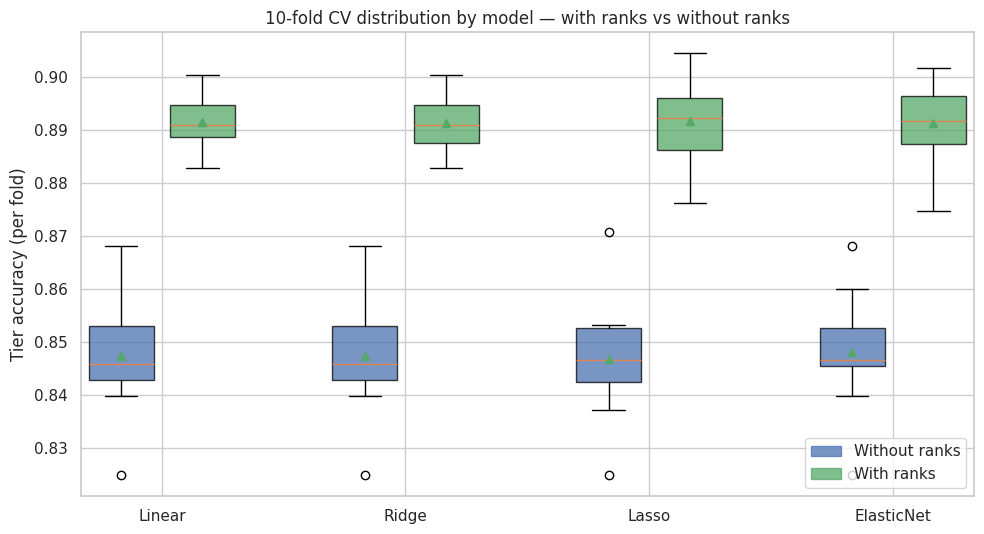

In [12]:
# Grouped boxplot of the per-fold CV accuracies
colours = {"Without ranks": "#4C72B0", "With ranks": "#55A868"}
fig, ax = plt.subplots(figsize=(10, 5.5))
positions, box_data, box_colours = [], [], []
for i, m in enumerate(model_names):
    for j, set_name in enumerate(["Without ranks", "With ranks"]):
        positions.append(i * 3 + j)
        box_data.append(cv_scores[(m, set_name)])
        box_colours.append(colours[set_name])

bp = ax.boxplot(box_data, positions=positions, widths=0.8,
                patch_artist=True, showmeans=True)
for patch, col in zip(bp["boxes"], box_colours):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

ax.set_xticks([i * 3 + 0.5 for i in range(len(model_names))])
ax.set_xticklabels(model_names)
ax.set_ylabel("Tier accuracy (per fold)")
ax.set_title("10-fold CV distribution by model — with ranks vs without ranks")
ax.legend(handles=[mpatches.Patch(color=c, label=s, alpha=0.75)
                   for s, c in colours.items()], loc="lower right")
plt.tight_layout()
plt.show()

## 8. Confusion matrices — best model, with vs without ranks

Best combination by CV mean accuracy: Lasso  |  With ranks



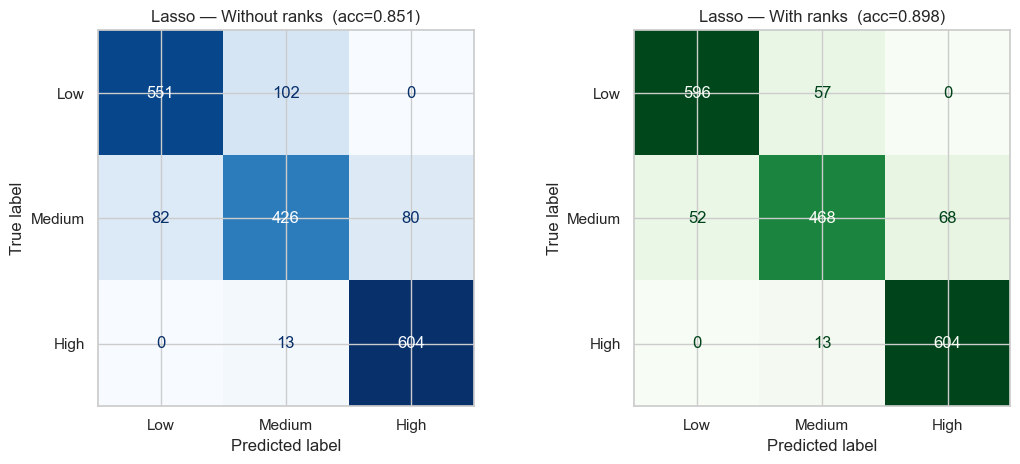

Classification report — Lasso, With ranks:



              precision    recall  f1-score   support

        High      0.899     0.979     0.937       617
         Low      0.920     0.913     0.916       653
      Medium      0.870     0.796     0.831       588

    accuracy                          0.898      1858
   macro avg      0.896     0.896     0.895      1858
weighted avg      0.897     0.898     0.896      1858



In [ ]:
best_model, best_set = cv_summary.sort_values("CV mean", ascending=False).iloc[0][["Model", "Feature set"]]
print(f"Best combination by CV mean accuracy: {best_model}  |  {best_set}\n")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, set_name, cmap in zip(axes, ["Without ranks", "With ranks"], ["Blues", "Greens"]):
    y_true, y_pred = holdout_detail[(best_model, set_name)]
    cm = confusion_matrix(y_true, y_pred, labels=tier_order)
    ConfusionMatrixDisplay(cm, display_labels=tier_order).plot(
        cmap=cmap, ax=ax, colorbar=False, values_format="d")
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{best_model} — {set_name}  (acc={acc:.3f})")
plt.tight_layout()
plt.show()

print(f"Classification report — {best_model}, {best_set}:\n")
y_true, y_pred = holdout_detail[(best_model, best_set)]
print(classification_report(y_true, y_pred, digits=3))

### Classification reports for all models and feature sets

In [13]:
for (model_name, set_name), (y_true, y_pred) in holdout_detail.items():
    print(f"Classification report — {model_name}, {set_name}:\n")
    print(classification_report(y_true, y_pred, digits=3))
    print("\n" + "="*60 + "\n")

Classification report — Linear, Without ranks:

              precision    recall  f1-score   support

        High      0.882     0.981     0.929       617
         Low      0.870     0.844     0.857       653
      Medium      0.788     0.723     0.754       588

    accuracy                          0.851      1858
   macro avg      0.847     0.849     0.847      1858
weighted avg      0.848     0.851     0.848      1858



Classification report — Ridge, Without ranks:

              precision    recall  f1-score   support

        High      0.882     0.981     0.929       617
         Low      0.870     0.844     0.857       653
      Medium      0.788     0.723     0.754       588

    accuracy                          0.851      1858
   macro avg      0.847     0.849     0.847      1858
weighted avg      0.848     0.851     0.848      1858



Classification report — Lasso, Without ranks:

              precision    recall  f1-score   support

        High      0.883     0.979    

## 9. Summary

In [ ]:
final = cv_summary.merge(
    holdout.rename(columns={"Tier accuracy": "Hold-out acc"}),
    on=["Model", "Feature set"],
)[["Model", "Feature set", "Hold-out acc", "CV mean", "CV std"]]
final = final.sort_values(["Feature set", "CV mean"], ascending=[True, False])
print(final.round(4).to_string(index=False))

     Model   Feature set  Hold-out acc  CV mean  CV std
     Lasso    With ranks        0.8977   0.8919  0.0077
    Linear    With ranks        0.8977   0.8915  0.0048
     Ridge    With ranks        0.8983   0.8913  0.0050
ElasticNet    With ranks        0.9004   0.8913  0.0074
ElasticNet Without ranks        0.8509   0.8482  0.0109
     Lasso Without ranks        0.8509   0.8475  0.0117
    Linear Without ranks        0.8509   0.8474  0.0109
     Ridge Without ranks        0.8509   0.8474  0.0109


### Findings

- **Method.** Four regressions (Linear, Ridge, Lasso, Elastic Net) each predict the continuous `overall_score`; the prediction is binned into Low / Medium / High using the brief's cut-offs (≤ 18, ≤ 28, else High).
- **With vs without ranks.** Adding the eight component rank columns raises accuracy for every model and tightens the fold-to-fold spread (see the grouped bar and boxplot).
- **Regularisation.** Ridge, Lasso and Elastic Net perform very close to ordinary least squares here — the signal is strong and the feature count is modest, so shrinkage neither helps nor hurts much. The CV boxplot shows their fold distributions largely overlap.
- **Cross-validation** confirms the ranking of models and feature sets is stable, not a single-split artefact.
- Most residual errors sit between neighbouring tiers (Low↔Medium, Medium↔High), expected since the tiers are contiguous bands of one underlying score.